In [1]:
# imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import re

from imblearn.over_sampling import SMOTE
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.metrics import Precision, Recall
import shap
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_METAL_DEVICE_FORCE_SYNC"] = "1"
os.environ["KERAS_BACKEND"] = "tensorflow"  # not strictly necessary, but safe

# disable GPU completely
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")

# root data folder (edit if needed)
DATA_DIR = Path("../Datasets/Open University Learning Analytics Dataset (OULAD)")

# csv file names
CSV_FILES = {
    "courses": "courses.csv",
    "assessments": "assessments.csv",
    "vle": "vle.csv",
    "studentInfo": "studentInfo.csv",
    "studentRegistration": "studentRegistration.csv",
    "studentAssessment": "studentAssessment.csv",
    "studentVLE": "studentVLE.csv",
}

# categorical columns to load as pandas 'category' to save memory
CAT_COLS = {
    "courses": ["code_module", "code_presentation"],
    "assessments": ["code_module", "code_presentation", "assessment_type"],
    "vle": ["code_module", "code_presentation", "activity_type"],
    "studentInfo": ["code_module", "code_presentation", "gender", "region",
                    "highest_education", "imd_band", "age_band", "disability", "final_result"],
    "studentRegistration": ["code_module", "code_presentation"],
    "studentAssessment": [],
    "studentVLE": ["code_module", "code_presentation"],
}

In [2]:
# ---------------------------
# data loading
# ---------------------------

def load_oulad_data(data_dir: Path, csv_files: dict, cat_cols: dict) -> dict[str, pd.DataFrame]:
    """load all OULAD CSV's into a dictionary of dataframes"""
    dfs = {}
    for name, file in csv_files.items():
        path = data_dir / file
        dtype_map = {col: "category" for col in cat_cols.get(name, [])}
        dfs[name] = pd.read_csv(path, dtype=dtype_map, low_memory=False)
    return dfs

# ---------------------------
# feature builders
# ---------------------------

def add_early_cutoff_to_courses(courses: pd.DataFrame, cutoff_pct: float) -> pd.DataFrame:
    """add a column 'early_cutoff' = cutoff_pct * module_presentation_length"""
    courses = courses.copy()
    courses["early_cutoff"] = cutoff_pct * courses["module_presentation_length"]
    return courses

def build_aggregated_vle_features(studentVLE: pd.DataFrame, courses: pd.DataFrame) -> pd.DataFrame:
    """aggregate studentVLE interactions up to the early cutoff"""
    # merge to get early_cutoff (left join on module + presentation)
    vle = studentVLE.merge(
        courses[["code_module", "code_presentation", "early_cutoff"]],
        on=["code_module", "code_presentation"],
        how="left"
    )
    # keep only records <= cutoff days
    vle = vle[vle["date"] <= vle["early_cutoff"]]

    # aggregate clicks and unique days
    agg = (vle.groupby(["id_student", "code_module", "code_presentation"], observed=True)
              .agg(sum_click=("sum_click", "sum"),
                   days_clicked=("date", "nunique"))
              .reset_index())
    return agg

def build_aggregated_assessment_features(studentAssessment: pd.DataFrame, assessments: pd.DataFrame, courses: pd.DataFrame) -> pd.DataFrame:
    """create weighted early assessment features and fail flags up to early cutoff"""
    # join studentAssessment -> assessments (to get weight, type, due date)
    df = studentAssessment.merge(
        assessments[["id_assessment", "code_module", "code_presentation",
                     "assessment_type", "date", "weight"]],
        on="id_assessment", how="left"
    )
    # bring in early cutoff
    df = df.merge(
        courses[["code_module", "code_presentation", "early_cutoff"]],
        on=["code_module", "code_presentation"],
        how="left"
    )

    # filter: drop Exams, keep only submissions <= cutoff, keep rows with score
    mask = (
        (df["assessment_type"] != "Exam") &
        (df["date_submitted"] <= df["early_cutoff"]) &
        (df["score"].notna())
    )
    df = df[mask].copy()

    # binary fail flag per assessment
    df["failed_assessment"] = (df["score"] < 40).astype(int)

    # weighted component
    df["weighted_score"] = df["score"] * df["weight"]

    # aggregate to enrolment level
    agg = (df.groupby(["id_student", "code_module", "code_presentation"], observed=True)
             .agg(early_weighted_avg_score=("weighted_score", "sum"),
                  total_weight=("weight", "sum"))
             .reset_index())

    # compute weighted average
    agg["early_weighted_avg_score"] = agg["early_weighted_avg_score"] / agg["total_weight"]
    agg.drop(columns="total_weight", inplace=True)

    # any fail?
    early_fail_flag = (df.groupby(["id_student", "code_module", "code_presentation"], observed=True)
                         ["failed_assessment"].max()
                         .reset_index()
                         .rename(columns={"failed_assessment": "early_failed_assessment"}))

    # merge back
    agg = agg.merge(early_fail_flag,
                    on=["id_student", "code_module", "code_presentation"],
                    how="left")
    return agg

def assemble_aggregated_master_table(dfs: dict[str, pd.DataFrame], vle_feats: pd.DataFrame,assess_feats: pd.DataFrame,cutoff_col: str = "early_cutoff") -> pd.DataFrame:
    """merge everything into one enrolment-level dataframe"""
    # start from studentInfo (one row per enrolment)
    df = dfs["studentInfo"].copy()

    # add registration info
    df = df.merge(
        dfs["studentRegistration"],
        on=["id_student", "code_module", "code_presentation"],
        how="left"
    )

    # add courses (for module length & cutoff)
    df = df.merge(
        dfs["courses"][["code_module", "code_presentation", "module_presentation_length", cutoff_col]],
        on=["code_module", "code_presentation"], how="left"
    )

    # add vle features
    df = df.merge(
        vle_feats,
        on=["id_student", "code_module", "code_presentation"],
        how="left"
    )

    # add assessment features
    df = df.merge(
        assess_feats,
        on=["id_student", "code_module", "code_presentation"],
        how="left"
    )

    # create enrolment instance id
    df["enrolment_instance_id"] = (
        df["id_student"].astype(str) + "_" +
        df["code_module"].astype(str) + "_" +
        df["code_presentation"].astype(str)
    )

    # drop enrolments withdrawn before cutoff
    df = df[
        (df["date_unregistration"].isna()) |
        (df["date_unregistration"] >= df[cutoff_col])
    ]

    return df

In [3]:
# ---------------------------
# encoding & cleaning
# ---------------------------

def encode_and_clean(df: pd.DataFrame) -> pd.DataFrame:
    """apply all the ordinal/binary encodings and handle missing values"""
    df = df.copy()

    # binary targets & flags
    df["failed_course"] = df["final_result"].apply(lambda x: 0 if x in ["Pass", "Distinction"] else 1).astype("Int64")
    df["has_early_assessment"] = df["early_weighted_avg_score"].notna().astype("Int64")

    # binary
    df["disability"] = df["disability"].map({"Y": 1, "N": 0}).astype("Int64")
    df["gender"] = df["gender"].map({"M": 1, "F": 0}).astype("Int64")

    # ordinal age_band
    age_order = ["0-35", "35-55", "55<="]
    df["age_band"] = df["age_band"].cat.set_categories(age_order, ordered=True).cat.codes.astype("Int64")

    # ordinal highest_education
    edu_order = ["No Formal quals", "Lower Than A Level", "A Level or Equivalent",
                 "HE Qualification", "Post Graduate Qualification"]
    df["highest_education"] = df["highest_education"].cat.set_categories(edu_order, ordered=True).cat.codes.astype("Int64")

    # imd_band with Unknown
    if "Unknown" not in df["imd_band"].cat.categories:
        df["imd_band"] = df["imd_band"].cat.add_categories("Unknown")
    df["imd_band"] = df["imd_band"].fillna("Unknown")
    imd_order = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%",
                 "60-70%", "70-80%", "80-90%", "90-100%", "Unknown"]
    df["imd_band"] = df["imd_band"].cat.set_categories(imd_order, ordered=True).cat.codes.astype("Int64")

    # missing date_registration rows are unusable
    df = df[df["date_registration"].notna()]

    # fillna for vle & assess metrics
    df["sum_click"] = df["sum_click"].fillna(0)
    df["days_clicked"] = df["days_clicked"].fillna(0)
    df["early_failed_assessment"] = df["early_failed_assessment"].fillna(0).astype(int)
    df["early_weighted_avg_score"] = df["early_weighted_avg_score"].fillna(-1)

    # convert pandas Int64 (nullable) to plain int
    int_cols = df.select_dtypes(include="Int64").columns
    df[int_cols] = df[int_cols].astype(int)

    return df

def tidy_columns(df: pd.DataFrame) -> pd.DataFrame:
    """drop unused, order remaining, and return a clean df ready for split"""
    cols_to_drop = [
        "id_student", "final_result", "date_unregistration",
        "module_presentation_length", "early_cutoff"
    ]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    ordered_cols = [
        "failed_course", "enrolment_instance_id", "date_registration",
        "gender", "age_band", "region", "imd_band", "highest_education",
        "disability", "studied_credits", "num_of_prev_attempts",
        "sum_click", "days_clicked", "has_early_assessment",
        "early_weighted_avg_score", "early_failed_assessment",
        "code_module", "code_presentation"
    ]
    ordered_cols = [c for c in ordered_cols if c in df.columns]
    df = df[ordered_cols]

    return df

In [4]:
def split_data(df: pd.DataFrame, target: str = "failed_course"):
    """
    Return train/val/test split and a fitted preprocessor.
    Keeps enrolment_instance_id for later analysis or joining back.
    """
    # separate enrolment_instance_id before dropping from features
    enrolment_ids = df["enrolment_instance_id"]

    # separate features and target
    X = df.drop(columns=[target, "enrolment_instance_id"])
    y = df[target]

    # identify column types
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # set up preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols)
        ],
        remainder="drop"
    )

    # ❶ first carve out the 10 % test
    X_trainval, X_test, y_trainval, y_test, id_trainval, id_test = train_test_split(
        X, y, enrolment_ids,
        test_size=test_size, stratify=y, random_state=random_state)

    # ❷ now split train/val (val_frac of the remaining 90 %)
    val_size = val_frac / (1 - test_size)           # -> 0.20 / 0.90 ≈ 0.222
    X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
        X_trainval, y_trainval, id_trainval,
        test_size=val_size, stratify=y_trainval, random_state=random_state)

    return (X_train.reset_index(drop=True), X_val.reset_index(drop=True), X_test.reset_index(drop=True),
            y_train.reset_index(drop=True), y_val.reset_index(drop=True), y_test.reset_index(drop=True),
            id_train.reset_index(drop=True), id_val.reset_index(drop=True), id_test.reset_index(drop=True),
            preprocessor)

    # # split all: X, y, enrolment IDs
    # X_train, X_test, y_train, y_test, enrolment_train, enrolment_test = train_test_split(
    #     X, y, enrolment_ids, test_size=0.2, stratify=y, random_state=42
    # )

    # return X_train, X_test, y_train, y_test, enrolment_train.reset_index(drop=True), enrolment_test.reset_index(drop=True), preprocessor

def split_data(df, target="failed_course", test_size=0.1, val_size=0.2, random_state=42):
    enrolment_ids = df["enrolment_instance_id"]
    X = df.drop(columns=[target, "enrolment_instance_id"])
    y = df[target]

    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols)
        ],
        remainder="drop"
    )

    # Split once into train+val and test
    X_temp, X_test, y_temp, y_test, id_temp, id_test = train_test_split(
        X, y, enrolment_ids, test_size=test_size, stratify=y, random_state=random_state
    )

    # Split train+val again
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
        X_temp, y_temp, id_temp, test_size=val_ratio, stratify=y_temp, random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test, id_train.reset_index(drop=True), id_val.reset_index(drop=True), id_test.reset_index(drop=True), preprocessor


In [5]:
# ---------------------------
# modeling utilities
# ---------------------------

def preprocess_to_array(preprocessor, X_train, X_test):
    """fit/transform train, transform test -> dense numpy arrays"""
    X_train_t = preprocessor.fit_transform(X_train)
    X_test_t  = preprocessor.transform(X_test)

    if hasattr(X_train_t, "toarray"):
        X_train_t = X_train_t.toarray()
        X_test_t = X_test_t.toarray()

    return X_train_t, X_test_t


def apply_rfe(X, y, n_features=100, step=0.1, random_state=42):
    """optional rfe on the transformed matrix using a simple logistic model"""
    estimator = LogisticRegression(max_iter=200, solver="liblinear", random_state=random_state)
    selector = RFE(estimator, n_features_to_select=n_features, step=step)
    selector.fit(X, y)
    return selector


def oversample_smote(X, y, random_state=42, k_neighbors=5):
    """smote on training data only"""
    safe_k = min(k_neighbors, X.shape[0] - 1) # avoid k_neighbors > n_samples in minority class
    sm = SMOTE(random_state=random_state, k_neighbors=safe_k)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res


def reshape_for_cnn(X):
    """reshape 2d features -> 3d (samples, features, 1) for conv1d"""
    return X.reshape(X.shape[0], X.shape[1], 1)

In [6]:
# ---------------------------
# metrics, plots & evaluation
# ---------------------------

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    pr_prec, pr_rec, _ = precision_recall_curve(y_true, y_prob)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": auc(pr_rec, pr_prec)
    }


def plot_confusion_matrix_cm(y_true, y_pred, labels=(0, 1), class_names=("Pass", "Fail"), title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha='center', va='center', fontsize=12)
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()


def plot_pr_curve(y_true, y_prob, title="Precision–Recall Curve (Fail class)"):
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    fig, ax = plt.subplots()
    ax.plot(rec, prec, color='darkorange', lw=2)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

def plot_evaluation_summary(y_true, y_pred, y_prob, labels=(0, 1), class_names=("Pass", "Fail")):
    """Plot confusion matrix and precision-recall curve side by side."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Model Evaluation Summary", fontsize=16)

    # --- Confusion Matrix ---
    im = axs[0].imshow(cm, cmap="Blues")
    axs[0].set_title("Confusion Matrix")
    axs[0].set_xlabel("Predicted")
    axs[0].set_ylabel("True")
    axs[0].set_xticks(range(len(labels)))
    axs[0].set_yticks(range(len(labels)))
    axs[0].set_xticklabels(class_names)
    axs[0].set_yticklabels(class_names)
    for (i, j), v in np.ndenumerate(cm):
        axs[0].text(j, i, str(v), ha='center', va='center')
    fig.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)

    # --- Precision–Recall Curve ---
    axs[1].plot(rec, prec, color='darkorange')
    axs[1].set_title("Precision–Recall Curve")
    axs[1].set_xlabel("Recall")
    axs[1].set_ylabel("Precision")
    axs[1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def evaluate_model(model, X_test, y_test, class_names=("Pass", "Fail"), verbose=True):
    y_proba = model.predict(X_test, verbose=0)
    if y_proba.ndim == 2 and y_proba.shape[1] > 1:
        y_prob1 = y_proba[:, 1]
        y_pred  = y_proba.argmax(axis=1)
    else:
        y_prob1 = y_proba.ravel()
        y_pred  = (y_prob1 >= 0.5).astype(int)

    if verbose:
        print(classification_report(y_test, y_pred, target_names=class_names, digits=2))
        print("roc-auc:", roc_auc_score(y_test, y_prob1).round(2))
        plot_evaluation_summary(y_test, y_pred, y_prob1, class_names=class_names)

    return y_pred, y_prob1



In [7]:
# ---------------------------
# CNN
# ---------------------------

def build_cnn(input_len, n_classes):
    inp = keras.Input(shape=(input_len, 1))
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(inp)
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)

    if n_classes == 2:
        out = layers.Dense(1, activation="sigmoid")(x)
        loss = "binary_crossentropy"
    else:
        out = layers.Dense(n_classes, activation="softmax")(x)
        loss = "sparse_categorical_crossentropy"

    model = keras.Model(inp, out)
    model.compile(optimizer="adam", loss=loss, metrics=[Precision(name="precision"), Recall(name="recall")])
    return model

def train_cnn(model, X_train, y_train, X_val, y_val, epochs=10, batch_size=32, verbose=1):
    cb = [keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_f1_score", mode="max")]
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, callbacks=cb, verbose=verbose)
    return hist


# ---------------------------
# alternate baseline models 
# ---------------------------

def transform_data(preprocessor, X_train, X_test, y_train, use_smote=False):
    Xtr = preprocessor.fit_transform(X_train)
    Xte = preprocessor.transform(X_test)
    if hasattr(Xtr, "toarray"):
        Xtr, Xte = Xtr.toarray(), Xte.toarray()
    ytr = y_train.copy()
    if use_smote:
        Xtr, ytr = oversample_smote(Xtr, ytr)
    return Xtr, Xte, ytr


def evaluate_probs(y_true, y_prob, threshold=0.5):
    return compute_binary_metrics(y_true, y_prob, threshold)


def baseline_logreg(preprocessor, X_train, X_test, y_train, y_test, use_smote=False):
    Xtr, Xte, ytr = transform_data(preprocessor, X_train, X_test, y_train, use_smote)
    model = LogisticRegression(max_iter=2000, class_weight=None if use_smote else "balanced")
    model.fit(Xtr, ytr)
    y_prob = model.predict_proba(Xte)[:, 1]
    metrics = evaluate_probs(y_test, y_prob)
    return {"name": "LogReg", "model": model, "Xtr": Xtr, "Xte": Xte,
            "y_prob": y_prob, "metrics": metrics}


def baseline_mlp(preprocessor, X_train, X_test, y_train, y_test, use_smote=False):
    Xtr, Xte, ytr = transform_data(preprocessor, X_train, X_test, y_train, use_smote)
    model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, early_stopping=True)
    model.fit(Xtr, ytr)
    y_prob = model.predict_proba(Xte)[:, 1]
    metrics = evaluate_probs(y_test, y_prob)
    return {"name": "MLP", "model": model, "Xtr": Xtr, "Xte": Xte,
            "y_prob": y_prob, "metrics": metrics}


def baseline_random_forest(preprocessor, X_train, X_test, y_train, y_test, use_smote=False):
    Xtr, Xte, ytr = transform_data(preprocessor, X_train, X_test, y_train, use_smote)
    model = RandomForestClassifier(n_estimators=100, class_weight=None if use_smote else "balanced", random_state=42)
    model.fit(Xtr, ytr)
    y_prob = model.predict_proba(Xte)[:, 1]
    metrics = evaluate_probs(y_test, y_prob)
    return {"name": "RF", "model": model, "Xtr": Xtr, "Xte": Xte,
            "y_prob": y_prob, "metrics": metrics}

In [8]:
# ---------------------------
# SHAP (unused in the end)
# ---------------------------
 
def shap_for_logreg(model, X_train_t, X_test_t, feature_names, sample=300):
    bg_idx = np.random.choice(X_train_t.shape[0], min(sample, X_train_t.shape[0]), replace=False)
    explainer = shap.LinearExplainer(model, X_train_t[bg_idx], feature_names=feature_names)
    sv = explainer.shap_values(X_test_t[:sample])
    shap.summary_plot(sv, X_test_t[:sample], feature_names=feature_names, plot_type="bar")
    shap.summary_plot(sv, X_test_t[:sample], feature_names=feature_names)

In [9]:
# ---------------------------
# data preparation
# ---------------------------

def prepare_data(data_dir, csv_files, cat_cols, cutoff_pct=0.25):
    """
    Loads and cleans the OULAD data, applies early cutoff, builds aggregate features,
    and returns the final cleaned DataFrame and fitted preprocessor.
    """
    dfs = load_oulad_data(data_dir, csv_files, cat_cols)
    dfs["courses"] = add_early_cutoff_to_courses(dfs["courses"], cutoff_pct=cutoff_pct)

    vle_feats = build_aggregated_vle_features(dfs["studentVLE"], dfs["courses"])
    assess_feats = build_aggregated_assessment_features(dfs["studentAssessment"], dfs["assessments"], dfs["courses"])

    df_master = assemble_aggregated_master_table(dfs, vle_feats, assess_feats)
    df_encoded = encode_and_clean(df_master)
    df_clean = tidy_columns(df_encoded)

    print(f"Final cleaned dataset shape: {df_clean.shape}")
    return df_clean

# ---------------------------
# main execution
# ---------------------------

# load and prepare data
df_clean = prepare_data(DATA_DIR, CSV_FILES, CAT_COLS)


Final cleaned dataset shape: (26252, 18)


Epoch 1/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6633 - precision: 0.5869 - recall: 0.6362 - val_loss: 0.6731 - val_precision: 0.4918 - val_recall: 0.8500
Epoch 2/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6144 - precision: 0.6640 - recall: 0.6446 - val_loss: 0.5720 - val_precision: 0.6300 - val_recall: 0.6541
Epoch 3/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5853 - precision: 0.6903 - recall: 0.6786 - val_loss: 0.5597 - val_precision: 0.6417 - val_recall: 0.6656
Epoch 4/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5706 - precision: 0.6999 - recall: 0.6957 - val_loss: 0.5924 - val_precision: 0.5714 - val_recall: 0.7893
Epoch 5/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5534 - precision: 0.7100 - recall: 0.7231 - val_loss: 0.5496 - val_precision: 0.6804 - val_recall: 0.6081
Epoch 6/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5371 - precision: 0.7333 - recall: 0.7076 - val_loss: 0.5529 - val_precision: 0.6633 - val_recall:

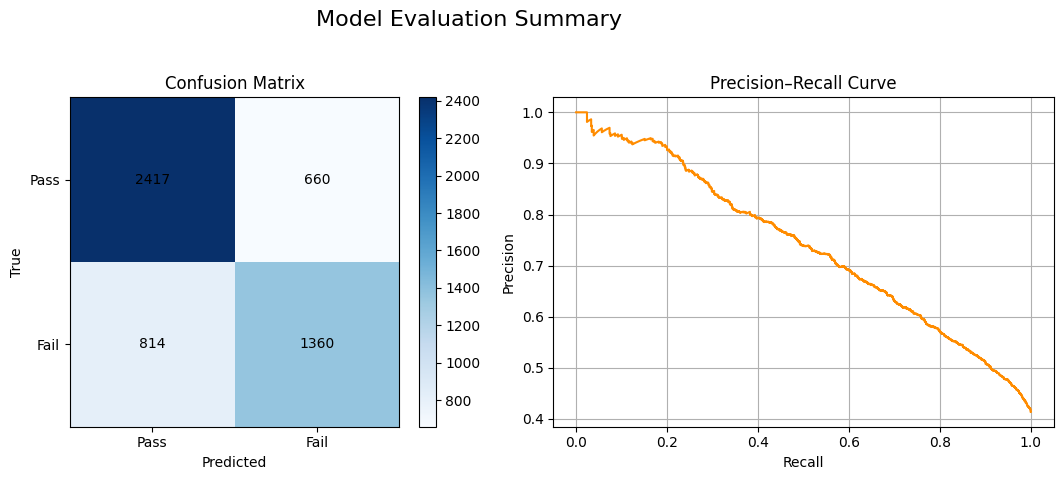

        Accuracy  Precision  Recall    F1  ROC_AUC  PR_AUC
LogReg      0.73       0.67    0.69  0.68     0.81    0.78
MLP         0.72       0.64    0.72  0.68     0.80    0.77
RF          0.74       0.70    0.66  0.68     0.80    0.77
CNN         0.72       0.67    0.63  0.65     0.78    0.74


In [10]:
# ---------------------------
# run models
# ---------------------------

# ---- configurable flags ----
USE_SMOTE_BASELINES = True
USE_RFE_CNN         = True
RFE_N_FEATURES      = 35
USE_SMOTE_CNN       = True
DO_SHAP_LOGREG      = False
SAVE_RESULTS_CSV    = False

def run_pipeline(df_clean, verbose=True, run_baselines=True, run_cnn=True):
    (X_train, X_val, X_test, y_train, y_val, y_test,
     id_train, id_val, id_test, preprocessor) = split_data(df_clean)

    results_rows = []

    if run_baselines:
        bl_logreg = baseline_logreg(preprocessor, X_train, X_val, y_train, y_val, use_smote=USE_SMOTE_BASELINES)
        results_rows.append((bl_logreg["name"], bl_logreg["metrics"]))

        bl_mlp = baseline_mlp(preprocessor, X_train, X_val, y_train, y_val, use_smote=USE_SMOTE_BASELINES)
        results_rows.append((bl_mlp["name"], bl_mlp["metrics"]))

        bl_rf = baseline_random_forest(preprocessor, X_train, X_val, y_train, y_val, use_smote=USE_SMOTE_BASELINES)
        results_rows.append((bl_rf["name"], bl_rf["metrics"]))

    if results_rows:
        baseline_df = pd.DataFrame({n: m for n, m in results_rows}).T
    else:
        baseline_df = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"])

    if run_cnn:
        X_train_t, X_val_t = preprocess_to_array(preprocessor, X_train, X_val)

        if USE_RFE_CNN:
            selector = apply_rfe(X_train_t, y_train, n_features=RFE_N_FEATURES)
            kept = np.where(selector.support_)[0]
            X_train_t = selector.transform(X_train_t)
            X_val_t = selector.transform(X_val_t)
            feat_names = np.array(preprocessor.get_feature_names_out())[kept]
        else:
            feat_names = preprocessor.get_feature_names_out()

        if USE_SMOTE_CNN:
            X_train_t, y_train = oversample_smote(X_train_t, y_train)

        if X_train_t.shape[1] == 0:
            raise ValueError(f"No features remain after RFE with k={RFE_N_FEATURES}")
        if X_train_t.shape[1] < 3:
            raise ValueError(f"Too few features ({X_train_t.shape[1]}) for CNN after RFE + SMOTE")

        X_train_cnn = reshape_for_cnn(X_train_t)
        X_val_cnn = reshape_for_cnn(X_val_t)

        cnn = build_cnn(input_len=X_train_cnn.shape[1], n_classes=2)
        _ = train_cnn(cnn, X_train_cnn, y_train, X_val_cnn, y_val,
                      10, batch_size=32, verbose=int(verbose))

        y_pred_val, y_prob_val = evaluate_model(cnn, X_val_cnn, y_val, verbose=verbose)
        cnn_metrics = compute_binary_metrics(y_val, y_prob_val)

        baseline_df.loc["CNN"] = pd.Series(cnn_metrics)

        return baseline_df, {
            "cnn": {
                "model": cnn,
                "X_test": X_test,
                "y_test": y_test,
                "feature_names": feat_names,
                "enrolment_ids": id_test
            }
        }

    return baseline_df, {}

# actually run it
results, models = run_pipeline(df_clean, run_baselines=True, run_cnn=True)
print(results.round(2))

In [ ]:
def gridsearch_cnn_rfe_smote(df_clean, rfe_values=[5, 10, 15, 25, 34], smote_options=[True, False]):
    results = []
    best_f1 = -1
    best_combo = None
    best_artifacts = None

    for use_smote in smote_options:
        global USE_SMOTE_CNN
        USE_SMOTE_CNN = use_smote

        for k in rfe_values:
            global RFE_N_FEATURES
            RFE_N_FEATURES = k

            print(f"---- RFE_N_FEATURES = {k}, SMOTE = {use_smote} ----")

            try:
                df_metrics, artifacts = run_pipeline(df_clean, verbose=False, run_baselines=False, run_cnn=True)

                df_metrics["RFE_N_FEATURES"] = k
                df_metrics["SMOTE"] = use_smote
                results.append(df_metrics)

                cnn_row = df_metrics.loc["CNN"]
                f1 = cnn_row["F1"]
                pr_auc = cnn_row["PR_AUC"]
                print(f"CNN → F1: {f1:.3f}, PR_AUC: {pr_auc:.3f}\n")

                if f1 > best_f1:
                    best_f1 = f1
                    best_combo = (k, use_smote)
                    best_artifacts = artifacts["cnn"]
                    best_artifacts["f1"] = f1
                    best_artifacts["pr_auc"] = pr_auc
                    best_artifacts["rfe_n"] = k
                    best_artifacts["use_smote"] = use_smote

            except Exception as e:
                print(f"⚠️ Error for RFE={k}, SMOTE={use_smote}: {e}\n")

    return results, best_artifacts
 
def plot_cnn_gridsearch_results(results):
    df_combined = pd.concat(results).reset_index().rename(columns={"index": "Model"})
    cnn_df = df_combined[df_combined["Model"] == "CNN"]

    plt.figure(figsize=(10, 5))
    for smote_status, group in cnn_df.groupby("SMOTE"):
        label_suffix = "with SMOTE" if smote_status else "without SMOTE"
        plt.plot(group["RFE_N_FEATURES"], group["F1"], marker="o", label=f"F1 {label_suffix}")
        plt.plot(group["RFE_N_FEATURES"], group["PR_AUC"], marker="s", label=f"PR AUC {label_suffix}")

    plt.xlabel("Number of Features (RFE_N_FEATURES)")
    plt.ylabel("Score")
    plt.title("CNN Performance: RFE Feature Counts and SMOTE Impact")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# run the grid search for CNN with RFE and SMOTE
results, best_model_artifacts = gridsearch_cnn_rfe_smote(df_clean)
plot_cnn_gridsearch_results(results)

---- RFE_N_FEATURES = 5, SMOTE = True ----


Epoch 1/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6194 - precision: 0.6647 - recall: 0.6063 - val_loss: 0.5537 - val_precision: 0.6848 - val_recall: 0.5837
Epoch 2/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5656 - precision: 0.7163 - recall: 0.6704 - val_loss: 0.5460 - val_precision: 0.6514 - val_recall: 0.6927
Epoch 3/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5600 - precision: 0.7271 - recall: 0.6706 - val_loss: 0.5577 - val_precision: 0.6036 - val_recall: 0.7479
Epoch 4/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5514 - precision: 0.7284 - recall: 0.6600 - val_loss: 0.5341 - val_precision: 0.6816 - val_recall: 0.6569
Epoch 5/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5530 - precision: 0.7288 - recall: 0.6611 - val_loss: 0.5410 - val_precision: 0.6702 - val_recall: 0.6766
Epoch 6/10
673/673 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5477 - precision: 0.7381 - recall: 0.6573 - val_loss: 0.5461 - val_precision: 0.6366 - val_recall:

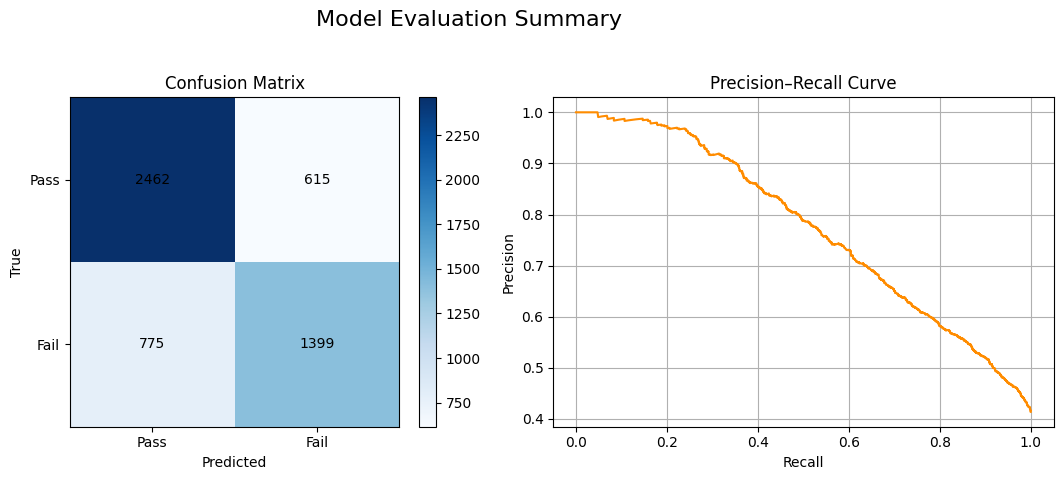

In [ ]:
USE_RFE_CNN         = True
RFE_N_FEATURES      = 10
USE_SMOTE_CNN       = True
df, artifacts = run_pipeline(df_clean, verbose=True)

In [ ]:
# RFE_N_FEATURES = 10           
# USE_SMOTE_CNN = True        
# USE_RFE_CNN = True        

# # --- call run_pipeline with final_test=True to train on train+val and test on test set ---
# final_df, best_test_artifacts = run_pipeline(
#     df_clean,
#     verbose=True,
#     run_baselines=False,
#     run_cnn=True,
#     final_test=True  # <– IMPORTANT: trains on 90%, tests on 10%
# )

# # --- Print the test set performance of CNN ---
# cnn_test_row = final_df.loc["CNN"]
# print("\n📊 Final CNN model performance on TEST set:")
# print(cnn_test_row.round(3))

# # Optional: display test predictions for inspection
# y_pred = best_test_artifacts["y_pred"]
# y_prob = best_test_artifacts["y_prob"]
# y_true = best_test_artifacts["y_test"]
# ids = best_test_artifacts["enrolment_ids"]

# df_preds = pd.DataFrame({
#     "enrolment_instance_id": ids,
#     "true": y_true,
#     "predicted": y_pred,
#     "prob_fail": y_prob.round(3)
# })
# df_preds.head(10)


In [ ]:
# ---------------------------
# LIME explanation for CNN
# ---------------------------

def run_lime_on_cnn(model, X_train, X_test, feature_names, class_names, instance_idx=0, num_features=10):
    """
    Runs LIME explanation on a single CNN prediction.

    Args:
        model: Trained Keras CNN model
        X_train: Training data (reshaped for CNN)
        X_test: Test data (reshaped for CNN)
        feature_names: List of original feature names (flattened if CNN input)
        class_names: List of class labels (e.g., ["pass", "fail"])
        instance_idx: Index of instance in X_test to explain
        num_features: Number of features to display in explanation

    Returns:
        LIME explanation and plot
    """
    # flatten CNN input for LIME
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # define predict_proba wrapper for LIME
    def predict_fn(x):
        x_reshaped = x.reshape(x.shape[0], -1, 1)
        preds = model.predict(x_reshaped, verbose=0)
        return np.hstack([1 - preds, preds])

    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_flat,
        feature_names=feature_names,
        class_names=class_names,
        mode="classification",
        discretize_continuous=True
    )

    exp = explainer.explain_instance(
        data_row=X_test_flat[instance_idx],
        predict_fn=predict_fn,
        num_features=num_features
    )

    fig = exp.as_pyplot_figure()
    return exp, fig

In [ ]:
# ---------------------------
# Explain a specific CNN prediction for a student
# ---------------------------

def explain_cnn_prediction_for_student(model, X_test, y_test, feature_names, student_index=0, num_features=5, class_names=["Pass", "Fail"], enrolment_ids=None):
    """
    Explains a CNN prediction for a student using LIME, includes enriched context.

    Parameters:
    - model: Trained CNN model
    - X_test: 3D numpy array (n_samples, n_features, 1)
    - y_test: 1D array or Series
    - feature_names: List of feature names
    - student_index: Index of student to explain
    - num_features: Number of LIME explanation features to show
    - class_names: Labels for binary classes
    - enrolment_ids: Optional list/array of enrolment_instance_id per student
    """
    # flatten for LIME
    X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1])

    def predict_fn(x):
        probs = model.predict(x.reshape((x.shape[0], x.shape[1], 1)))
        return np.hstack([(1 - probs), probs])

    # initialise LIME explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_test_flat,
        feature_names=feature_names,
        class_names=class_names,
        discretize_continuous=True,
        mode='classification'
    )

    # explain this student's instance
    exp = explainer.explain_instance(
        data_row=X_test_flat[student_index],
        predict_fn=predict_fn,
        num_features=num_features
    )

    # format prediction
    x_input = X_test[student_index].reshape(1, -1, 1)
    prob = model.predict(x_input)[0][0]
    pred_class = int(prob >= 0.5)
    actual_class = y_test.iloc[student_index] if hasattr(y_test, "iloc") else y_test[student_index]
    fail_prob = prob * 100
    pred_label = f"{class_names[pred_class]} ({fail_prob:.0f}% probability of fail)"

    print(f"________________________________________\nStudent Index: {student_index}")
    print(f"Enrolment Instance ID: {enrolment_ids[student_index]}")
    print(f"Predicted: {pred_label}")
    print(f"Actual:    {class_names[actual_class]}")

    print("\nTop Contributing Features:")
    student_row = X_test_flat[student_index]
    feature_list = list(feature_names)

    for feature, weight in exp.as_list(label=1):
        # extract real feature name from the LIME string
        matching_names = [fname for fname in feature_list if fname in feature]
        
        if matching_names:
            fname = matching_names[0]
            readable_name = fname.replace("num__", "").replace("cat__", "")  # strip prefix
            direction = "↑ Predictor of Fail" if weight > 0 else "↓ Predictor of Pass"
            value = student_row[feature_list.index(fname)]
            print(f"- {readable_name}: {value:.2f} ({direction})")
        else:
            print(f"- {feature}: [Unavailable in input] ({direction})")

    fig = exp.as_pyplot_figure(label=1)
    fig.axes[0].set_title(f"Feature contributions to the prediction for enrolment: {enrolment_ids[student_index]}")

    # Correctly assign colours based on feature name → weight
    fail_color = (1.0, 0.0, 0.0, 1.0) # red
    pass_color = (0.0, 0.5, 0.0, 1.0) # green

    # Map of feature text to weights
    exp_weights = dict(exp.as_list(label=1))

    for bar, text in zip(fig.axes[0].patches, fig.axes[0].get_yticklabels()):
        feature_str = text.get_text()
        weight = exp_weights.get(feature_str, 0)

        if weight > 0:
            bar.set_color(fail_color)  # predictor of fail
        else:
            bar.set_color(pass_color)  # predictor of pass

In [ ]:
# ---------------------------
# Explain a specific CNN prediction for a student
# ---------------------------
explain_cnn_prediction_for_student(
    model=best_model_artifacts["model"],
    X_test=best_model_artifacts["Xte"],
    y_test=best_model_artifacts["y_test"],
    feature_names=best_model_artifacts["feature_names"],
    enrolment_ids=best_model_artifacts.get("enrolment_ids", None),
    student_index=600,
    num_features=5
)

KeyError: 'Xte'